# Hybrid CNN–LSTM Model for News Topic Classification
### Deep Learning Approach on the Reuters Dataset



This notebook implements a hybrid architecture combining a **Convolutional Neural Network (CNN)** and **Long Short-Term Memory (LSTM)** to classify news articles into their respective topics using the **Reuters dataset**.

The workflow covers:

- Dataset loading and exploration
- Text preprocessing and sequence padding
- Vocabulary management
- Model architecture combining **CNN and LSTM**
- Model training with checkpointing and early stopping
- Performance evaluation on validation and test data
- Example predictions on unseen news articles

The goal is to demonstrate how combining **CNN (for local feature extraction)** and **LSTM (for sequential dependency modeling)** can improve performance in text classification tasks.

# Mounting to Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Importing Necesssary Libraries

In [16]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, SpatialDropout1D, Conv1D, MaxPooling1D, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.models import Sequential

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score

## Dataset Overview

The **Reuters dataset** is a widely used benchmark dataset for text classification.  
It contains newswire articles categorized into **multiple topics** such as economics, trade, grain, crude oil, etc.

The original dataset consists of **raw news articles associated with 46 topic labels**. Each document is a piece of text and each label corresponds to one of several news categories.

Topics mainly relate to **economic activities, commodities, and financial markets**. Examples of categories include:

- **earn** – company earnings reports  
- **acq** – acquisitions and mergers  
- **money-fx** – foreign exchange market news  
- **grain** – grain market information  
- **crude** – crude oil market news  
- **trade** – international trade discussions  
- **interest** – interest rate related news  
- **ship** – shipping and maritime trade  
- **wheat**, **corn**, **sugar**, etc.

In this notebook, I used the **preprocessed version provided by Keras** (`keras.datasets.reuters`). In this version:

- Texts are already **tokenized and converted into sequences of integers**
- Each integer represents the **index of a word in the vocabulary**
- The dataset is **cleaned and standardized**, making it ready for direct use in deep learning models
- The dataset is provided with **training and test splits**

This processed version allows us to focus directly on **modeling and learning semantic patterns from the text**.

Dataset Loading

In [3]:
(X_train_full, y_train_full), (X_test, y_test) = reuters.load_data()

print("Training samples:", len(X_train_full))
print("Test samples:", len(X_test))

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training samples: 8982
Test samples: 2246


# Initial Dataset Exploration

### Example sequences of encoded text

In [4]:
df_preview = pd.DataFrame({
    "sequence_tokens": X_train_full[:10],
    "label": y_train_full[:10],
    "sequence_length": [len(x) for x in X_train_full[:10]]
})

df_preview

,sequence_tokens,label,sequence_length
0,"[1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207, ...",3,87
1,"[1, 3267, 699, 3434, 2295, 56, 16784, 7511, 9,...",4,56
2,"[1, 53, 12, 284, 15, 14, 272, 26, 53, 959, 32,...",3,139
3,"[1, 4, 686, 867, 558, 4, 37, 38, 309, 2276, 46...",4,224
4,"[1, 8295, 111, 8, 25, 166, 40, 638, 10, 436, 2...",4,101
5,"[1, 4, 37, 38, 309, 213, 349, 1632, 48, 193, 2...",4,116
6,"[1, 56, 5539, 925, 149, 8, 16, 23, 931, 3875, ...",4,100
7,"[1, 53, 648, 26, 14, 749, 26, 39, 6207, 5466, ...",3,100
8,"[1, 178, 53, 321, 26, 14, 948, 26, 178, 39, 44...",3,82
9,"[1, 56, 7224, 81, 40, 1175, 174, 19892, 6, 179...",16,106


### Basic Dataset Statistics and Sample Inspection

In [5]:
num_classes = np.max(y_train_full) + 1

train_lengths = [len(x) for x in X_train_full]
test_lengths = [len(x) for x in X_test]

print("Number of classes:", num_classes)
print("Average training sequence length:", np.mean(train_lengths))
print("Maximum training sequence length:", np.max(train_lengths))
print("Minimum training sequence length:", np.min(train_lengths))

print("\nFirst training sample (token ids):")
print(X_train_full[0])

print("\nFirst training label:")
print(y_train_full[0])

Number of classes: 46
Average training sequence length: 145.5398574927633
Maximum training sequence length: 2376
Minimum training sequence length: 13

First training sample (token ids):
[1, 27595, 28842, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]

First training label:
3


### Text Lengths Distribution

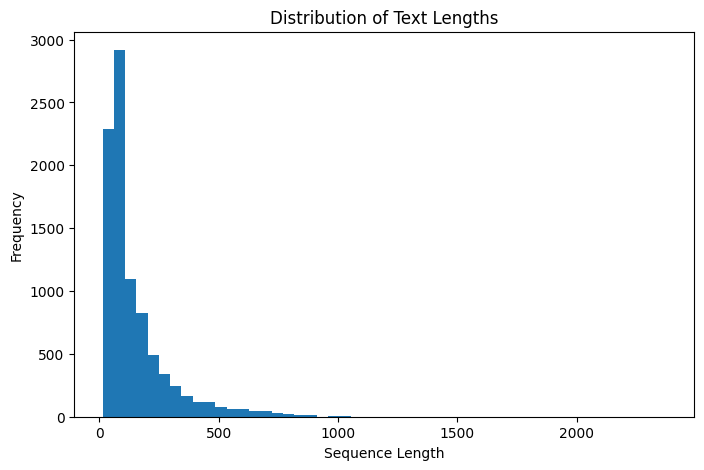

In [6]:
plt.figure(figsize=(8,5))
plt.hist(train_lengths, bins=50)
plt.title("Distribution of Text Lengths")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")

plt.show()

### Vocabulary Size of the Reuters Dataset

In [7]:
word_index = reuters.get_word_index()
print("Total vocabulary size:", len(word_index))

Total vocabulary size: 30979


### Label Distribution and Class Imbalance Analysis

In [8]:
unique_labels, counts = np.unique(y_train_full, return_counts=True)

print("Label distribution in training set:")
for label, count in zip(unique_labels, counts):
    print(f"Class {label}: {count} samples")

# Identify majority and minority classes
majority_index = np.argmax(counts)
minority_index = np.argmin(counts)

majority_class = unique_labels[majority_index]
minority_class = unique_labels[minority_index]

print("\nMajority class:")
print(f"Class {majority_class} with {counts[majority_index]} samples")

print("\nMinority class:")
print(f"Class {minority_class} with {counts[minority_index]} samples")

Label distribution in training set:
Class 0: 55 samples
Class 1: 432 samples
Class 2: 74 samples
Class 3: 3159 samples
Class 4: 1949 samples
Class 5: 17 samples
Class 6: 48 samples
Class 7: 16 samples
Class 8: 139 samples
Class 9: 101 samples
Class 10: 124 samples
Class 11: 390 samples
Class 12: 49 samples
Class 13: 172 samples
Class 14: 26 samples
Class 15: 20 samples
Class 16: 444 samples
Class 17: 39 samples
Class 18: 66 samples
Class 19: 549 samples
Class 20: 269 samples
Class 21: 100 samples
Class 22: 15 samples
Class 23: 41 samples
Class 24: 62 samples
Class 25: 92 samples
Class 26: 24 samples
Class 27: 15 samples
Class 28: 48 samples
Class 29: 19 samples
Class 30: 45 samples
Class 31: 39 samples
Class 32: 32 samples
Class 33: 11 samples
Class 34: 50 samples
Class 35: 10 samples
Class 36: 49 samples
Class 37: 19 samples
Class 38: 19 samples
Class 39: 24 samples
Class 40: 36 samples
Class 41: 30 samples
Class 42: 13 samples
Class 43: 21 samples
Class 44: 12 samples
Class 45: 18 sa

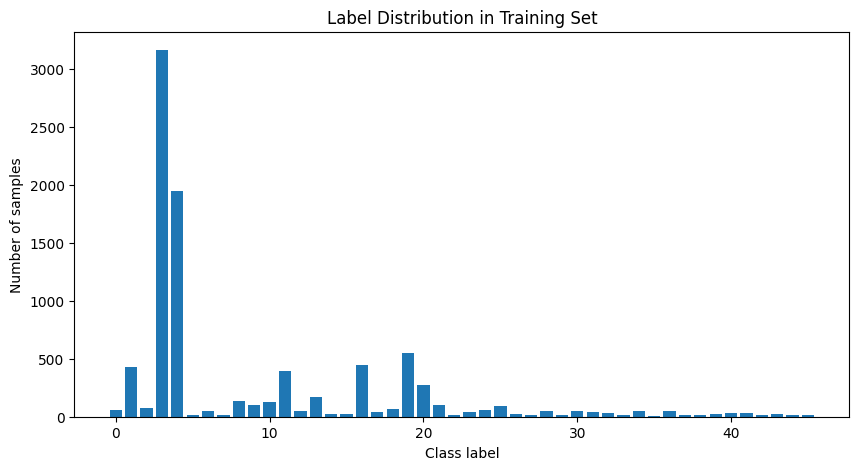

In [9]:
plt.figure(figsize=(10,5))
plt.bar(unique_labels, counts)
plt.title("Label Distribution in Training Set")
plt.xlabel("Class label")
plt.ylabel("Number of samples")
plt.show()

### Decoding a Tokenized News Article

In [10]:
word_index = reuters.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

decoded_text = " ".join([reverse_word_index.get(i - 3, "?") for i in X_train_full[0]])

print(decoded_text)

? mcgrath rentcorp said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3


In the Reuters dataset, indices 0–2 are reserved for special tokens:

*  0 for padding

*  1 for  start of sequence

*  2 for unknown word

Therefore the substraction of 3 was to map tokens back to the correct word index.
If the token is not found, "?" is returned

## Model Hyperparameters

In this section, key hyperparameters used for training the model are defined.  
The **maximum sequence length** was selected using a **percentile-based rule**. I worked with
**95th percentile**, meaning that **95% of the training sequences have a length smaller than or equal to this value**.  
This is to keep most information in the dataset.

In [11]:
np.percentile(train_lengths, 95)

np.float64(459.0)

In [4]:
vocab_size = 15000
max_len = 450 #percentile-based rule
embedding_dim = 128

batch_size = 64
epochs = 30

checkpoint_path = "/content/drive/MyDrive/cnn_lstm_best_model.keras"

### Loading the Reuters Dataset with the Defined Vocabulary Size

In [5]:
(X_train_full, y_train_full), (X_test, y_test) = reuters.load_data(num_words=vocab_size)

### Sequence Padding and Truncation

In [6]:
X_train_full = pad_sequences(X_train_full, maxlen=max_len, padding='post', truncating='post')
X_test = pad_sequences(X_test, maxlen=max_len, padding='post', truncating='post')

print("Train shape:", X_train_full.shape)
print("Test shape:", X_test.shape)

Train shape: (8982, 450)
Test shape: (2246, 450)


### Train–Validation Split with Stratified Sampling
I split the training set into **training and validation subsets**.  
The **stratified split** was used to preserve the same class distribution across both sets

In [7]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full
)

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (7185, 450)
Validation shape: (1797, 450)
Test shape: (2246, 450)


### CNN–LSTM Hybrid Model Architecture
I defined a hybrid model combining a CNN and a Bidirectional LSTM with respect to the following:
*   The **Embedding layer** transforms word indices into dense vector representations.  
*   **Convolutional layers** extract local patterns such as important word combinations, while **max pooling** reduces dimensionality and keeps the most relevant features.
*   The **Bidirectional LSTM** captures sequential dependencies from both past and future contexts in the text.
*   The **Dense layer** is a fully connected layer to combine learned features.

Techniques:
*   **Spatial Dropout** & **Dropout** were used as regularization techniques that randomly drop respectively entire embedding features and neuron activations during training to reduce overfitting.
*   **MaxPooling** served to reduce sequence length by keeping the maximum value in each window (pool_size = 2 downsamples the sequence by taking the maximum of every 2 elements)
*   **Recurrent Dropout** drops some connections inside the LSTM across timesteps; it randomly ignores part of information (hidden activations) coming from previous timestep (previous position in the sequence)


In [16]:
model = Sequential([
    tf.keras.Input(shape=(max_len,)),

    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SpatialDropout1D(0.3),

    Conv1D(filters=128, kernel_size=5, activation='relu'),
    MaxPooling1D(pool_size=2),

    Conv1D(filters=64, kernel_size=3, activation='relu'),

    Bidirectional(LSTM(32, dropout=0.2, recurrent_dropout=0.2)),

    Dense(64, activation='relu'),
    Dropout(0.4),

    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 450, 128)       │     1,920,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 450, 128)       │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 446, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 223, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 221, 64)        │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 46)             │         2,990 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,058,670 (7.85 MB)

 Trainable params: 2,058,670 (7.85 MB)

 Non-trainable params: 0 (0.00 B)

### Training Callbacks for Model Optimization

In [17]:
checkpoint_callback = ModelCheckpoint(filepath=checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

### Model Training

In [18]:
# Train from checkpoint if it exists, otherwise start from scratch
if os.path.exists(checkpoint_path):
    print("Checkpoint found. Loading saved model and resuming from it...")
    model = load_model(checkpoint_path)
else:
    print("No checkpoint found. Starting training from scratch...")

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=epochs,
    batch_size=batch_size,
    callbacks=[checkpoint_callback, early_stopping],
    verbose=1
)

No checkpoint found. Starting training from scratch...
Epoch 1/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.3657 - loss: 2.7389
Epoch 1: val_loss improved from inf to 1.68738, saving model to /content/drive/MyDrive/cnn_lstm_best_model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 180s 1s/step - accuracy: 0.3663 - loss: 2.7346 - val_accuracy: 0.5782 - val_loss: 1.6874
Epoch 2/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5729 - loss: 1.6686
Epoch 2: val_loss improved from 1.68738 to 1.59438, saving model to /content/drive/MyDrive/cnn_lstm_best_model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.5729 - loss: 1.6689 - val_accuracy: 0.5971 - val_loss: 1.5944
Epoch 3/30
113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6053 - loss: 1.5670
Epoch 3: val_loss improved from 1.59438 to 1.52914, saving model to /content/drive/MyDrive/cnn_lstm_best_model.keras
113/113 ━━━━━━━━━━━━━━━━━━━━ 172s 2s/step - accuracy: 0.6053 - loss: 1.5668 - val_accuracy: 0.6366 - val_lo

### Training & Validation Results

In [17]:
model = load_model(checkpoint_path)

train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)

# Predictions
y_train_pred = np.argmax(model.predict(X_train), axis=1)
y_val_pred = np.argmax(model.predict(X_val), axis=1)

# Weighted F1-score
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
val_f1 = f1_score(y_val, y_val_pred, average='weighted')

print("Training results")
print("Train Accuracy:", train_acc)
print("Train Loss:", train_loss)
print("Train F1-score (weighted):", train_f1)

print("\nValidation results")
print("Validation Accuracy:", val_acc)
print("Validation Loss:", val_loss)
print("Validation F1-score (weighted):", val_f1)

225/225 ━━━━━━━━━━━━━━━━━━━━ 62s 274ms/step
57/57 ━━━━━━━━━━━━━━━━━━━━ 15s 270ms/step
Training results
Train Accuracy: 0.7990257740020752
Train Loss: 0.772760808467865
Train F1-score (weighted): 0.7657943358008389

Validation results
Validation Accuracy: 0.7056204676628113
Validation Loss: 1.3080474138259888
Validation F1-score (weighted): 0.6762352816871575


### Model Evaluation on the Test Set

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

# Predictions
y_test_pred = np.argmax(model.predict(X_test), axis=1)
# Weighted F1-score
test_f1 = f1_score(y_test, y_test_pred, average='weighted')

print("Test results")
print("Test Accuracy:", test_acc)
print("Test Loss:", test_loss)
print("Test F1-score (weighted):", test_f1)

71/71 ━━━━━━━━━━━━━━━━━━━━ 20s 281ms/step
Test results
Test Accuracy: 0.687889575958252
Test Loss: 1.3106707334518433
Test F1-score (weighted): 0.6634190100453479


### Function for Decoding Test News Articles

In [22]:
word_index = reuters.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_news(sequence):
    return " ".join(reverse_word_index.get(i - 3, "?") for i in sequence if i > 3)

### Generating Predictions on the Test Set

In [23]:
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

71/71 ━━━━━━━━━━━━━━━━━━━━ 23s 313ms/step


### Sample Predictions on Test Articles

In [24]:
n_examples = 5

results = []

for i in range(n_examples):
    text = decode_news(X_test[i])

    results.append({
        "Text": text[:400],   # truncate for readability
        "True Label": y_test[i],
        "Predicted Label": y_pred[i]
    })

df_results = pd.DataFrame(results)
df_results

,Text,True Label,Predicted Label
0,the great atlantic and pacific tea co said its...,3,16
1,philippine sugar production in the 1987 88 cro...,10,9
2,the agriculture department's widening of louis...,1,1
3,graham mccormick oil and gas partnership said ...,4,4
4,strong south winds were keeping many vessels t...,4,13


## Model Performance Summary

After training the CNN–LSTM model, its performance was evaluated on the **training, validation, and test sets**.

The model achieved a **training accuracy of about 80%** and an **f1-score of 76.57%**, so it successfully learned meaningful patterns from the training data. On the **validation set**, the accuracy reached approximately **70.6%** and the f1-score was about **67.62%**, with a higher loss compared to the training set, which suggests a moderate level of **overfitting**.

Finally, evaluation on the **test set** resulted in an accuracy of about **68.8%** and the f1-score has reached **66.34%**, which is close to the validation performance. This indicates that the model generalizes reasonably in a good way to unseen news articles, although some performance degradation was expected when moving from training to unseen data.

Overall, the results show that the **CNN–LSTM architecture is able to learn both local textual patterns (via CNN) and sequential dependencies (via LSTM)** for multi-class news classification task.

---

 *Realized by*  
**Khawla Chrifi Alaoui**

---